In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/DrDoS_DNS.csv")

In [ ]:
df.head()

,protocol,flow_duration,total_forward_packets,total_backward_packets,total_forward_packets_length,total_backward_packets_length,forward_packet_length_mean,backward_packet_length_mean,forward_packets_per_second,backward_packets_per_second,forward_iat_mean,backward_iat_mean,flow_iat_mean,flow_packets_per_seconds,flow_bytes_per_seconds,label
0,17,2468,4,0,1580.0,0.0,395.0,0.0,1620.745543,0.0,822.666667,0.0,822.666667,1620.745543,6.401945e+05,DrDoS_DNS
1,17,133,4,0,5888.0,0.0,1472.0,0.0,30075.187970,0.0,44.333333,0.0,44.333333,30075.187970,4.427068e+07,DrDoS_DNS
2,17,33509,200,0,88000.0,0.0,440.0,0.0,5968.545764,0.0,168.386935,0.0,168.386935,5968.545764,2.626160e+06,DrDoS_DNS
3,17,288495,200,0,88000.0,0.0,440.0,0.0,693.252916,0.0,1449.723618,0.0,1449.723618,693.252916,3.050313e+05,DrDoS_DNS
4,17,9,2,0,2062.0,0.0,1031.0,0.0,222222.222222,0.0,9.000000,0.0,9.000000,222222.222222,2.291111e+08,DrDoS_DNS


In [ ]:
df.dropna(inplace=True)

print(df.isna().sum())

protocol                         0
flow_duration                    0
total_forward_packets            0
total_backward_packets           0
total_forward_packets_length     0
total_backward_packets_length    0
forward_packet_length_mean       0
backward_packet_length_mean      0
forward_packets_per_second       0
backward_packets_per_second      0
forward_iat_mean                 0
backward_iat_mean                0
flow_iat_mean                    0
flow_packets_per_seconds         0
flow_bytes_per_seconds           0
label                            0
dtype: int64


In [ ]:
df["label"] = df["label"].replace({"BENIGN":0,"DrDoS_DNS":1})

/tmp/ipykernel_932/4286483957.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["label"] = df["label"].replace({"BENIGN":0,"DrDoS_DNS":1})


In [ ]:
df["label"].value_counts()

,count
label,
1,32797
0,1128


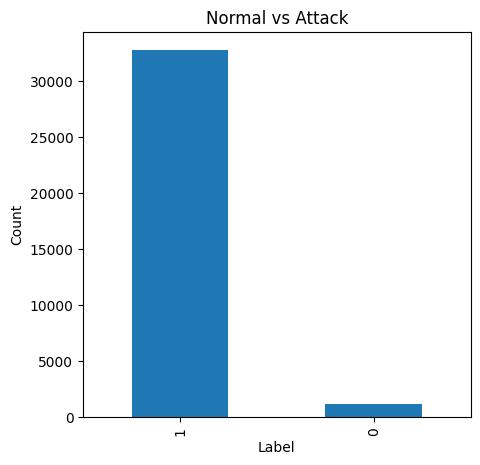

In [ ]:
plt.figure(figsize=(5,5))
df["label"].value_counts().plot(kind="bar")

plt.title("Normal vs Attack")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

In [ ]:
X = df[["flow_duration","total_forward_packets","total_backward_packets","flow_packets_per_seconds"]]
y = df["label"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [ ]:
prediction = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, prediction)

print(acc)

0.999901748870112


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, prediction)

print(cm)

[[ 334    0]
 [   1 9843]]


In [ ]:
depths = []
train_acc = []
test_acc = []

for d in range(1,13):

    model = DecisionTreeClassifier(max_depth=d, random_state=42)

    model.fit(X_train, y_train)

    tr = accuracy_score(y_train, model.predict(X_train))
    te = accuracy_score(y_test, model.predict(X_test))

    depths.append(d)

    train_acc.append(tr)

    test_acc.append(te)

    print("depth", d, "train =", round(tr,2), "| test =", round(te,2))


depth 1 train = 1.0 | test = 1.0
depth 2 train = 1.0 | test = 1.0
depth 3 train = 1.0 | test = 1.0
depth 4 train = 1.0 | test = 1.0
depth 5 train = 1.0 | test = 1.0
depth 6 train = 1.0 | test = 1.0
depth 7 train = 1.0 | test = 1.0
depth 8 train = 1.0 | test = 1.0
depth 9 train = 1.0 | test = 1.0
depth 10 train = 1.0 | test = 1.0
depth 11 train = 1.0 | test = 1.0
depth 12 train = 1.0 | test = 1.0


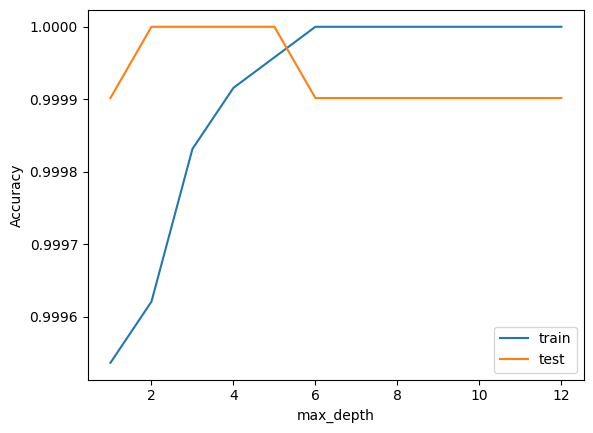

In [ ]:
plt.plot(depths, train_acc, label="train")

plt.plot(depths, test_acc, label="test")

plt.xlabel("max_depth")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

In [ ]:
best_depth=depths[test_acc.index(max(test_acc))]

print(best_depth)

2


In [ ]:
best_model=DecisionTreeClassifier(max_depth=best_depth,random_state=42)

best_model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=2, random_state=42)

In [ ]:
prediction=best_model.predict(X_test)

print(accuracy_score(y_test,prediction))

1.0


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       334
           1       1.00      1.00      1.00      9844

    accuracy                           1.00     10178
   macro avg       1.00      1.00      1.00     10178
weighted avg       1.00      1.00      1.00     10178



In [ ]:
flow=float(input("Flow Duration: "))

forward=int(input("Total Forward Packets: "))

backward=int(input("Total Backward Packets: "))

packets=float(input("Flow Packets Per Second: "))

user_df = pd.DataFrame([[flow, forward, backward, packets]], columns=['flow_duration', 'total_forward_packets', 'total_backward_packets', 'flow_packets_per_seconds'])

prediction = best_model.predict(user_df)[0]

if prediction == 1:
    print("🚨 Attack Detected!")
else:
    print("✅ Normal Traffic")

Flow Duration: 900
Total Forward Packets: 500
Total Backward Packets: 1
Flow Packets Per Second: 500000
🚨 Attack Detected!


In [ ]:
from IPython.display import Audio, display

probabilities = best_model.predict_proba(user_df)[0]
confidence = probabilities[prediction]

if prediction==1:

    sample_rate=44100
    duration=1
    frequency=1000

    t=np.linspace(0,duration,int(sample_rate*duration),False)
    sound=np.sin(2*np.pi*frequency*t)

    display(Audio(sound,rate=sample_rate,autoplay=True))

    print("="*40)
    print("CYBER SECURITY ALERT 🚨")
    print("Attack Detected")
    print(f"Risk Level : {confidence:.2f}%")
    print("="*40)

else:

    print("="*40)
    print("✅ Normal Traffic")
    print(f"Confidence : {confidence:.2f}%")
    print("="*40)

CYBER SECURITY ALERT 🚨
Attack Detected
Risk Level : 1.00%
